In [1]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df = df.iloc[:, :2]
df.columns = ["label", "message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [5]:
(df["label"].value_counts(normalize=True) * 100).round(2)

label
ham     86.59
spam    13.41
Name: proportion, dtype: float64

In [6]:
ps = PorterStemmer()
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

df["message"] = df["message"].apply(preprocess)


In [7]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["message"])

y = df["label"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)


In [10]:
print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred, pos_label="spam"))
print("Recall:", recall_score(y_test, nb_pred, pos_label="spam"))
print("F1:", f1_score(y_test, nb_pred, pos_label="spam"))
print(confusion_matrix(y_test, nb_pred))

Naive Bayes
Accuracy: 0.9659192825112107
Precision: 1.0
Recall: 0.7466666666666667
F1: 0.8549618320610687
[[965   0]
 [ 38 112]]


In [11]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [12]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, pos_label="spam"))
print("Recall:", recall_score(y_test, lr_pred, pos_label="spam"))
print("F1:", f1_score(y_test, lr_pred, pos_label="spam"))
print(confusion_matrix(y_test, lr_pred))

Logistic Regression
Accuracy: 0.9551569506726457
Precision: 0.9629629629629629
Recall: 0.6933333333333334
F1: 0.8062015503875969
[[961   4]
 [ 46 104]]


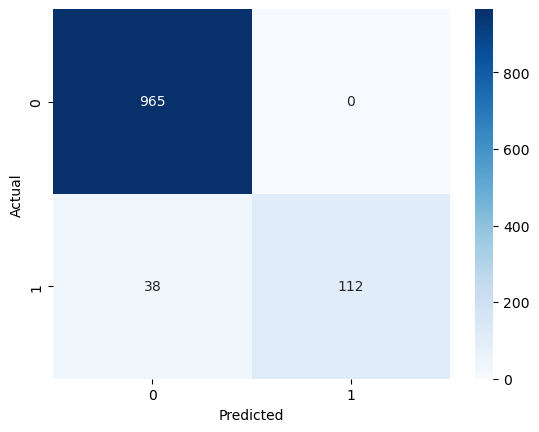

In [13]:
cm = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("heatmap4.png", dpi=300, bbox_inches="tight")
plt.show()